In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import shapely

In [157]:
## inputs
# Shape file of Florida state
shapeFilePath = r"Y:\Analytics\Documentation\Data Quality\Data Files\FL_State_ShapeFile.csv"
# specify grid size
n_cells=30

In [158]:
flData = pd.read_csv(shapeFilePath, sep="\t")

In [159]:
## Drop unrelated rows
flData = flData.dropna(subset=['geometry'])

In [160]:
flData.head()

,State,County,geometry
0,Florida,Baker,"POLYGON ((-82.4584 30.1364, -82.4582 30.2017, ..."
1,Florida,Bradford,"POLYGON ((-82.0942 29.7801, -82.0935 29.7812, ..."
2,Florida,Calhoun,"POLYGON ((-85.3898 30.2009, -85.3898 30.2032, ..."
3,Florida,Broward,"POLYGON ((-80.6648 25.9592, -80.8729 25.9794, ..."
4,Florida,Clay,MULTIPOLYGON (((-81.721600000000052 30.0506999...


In [161]:
flData['geometry'] = gpd.GeoSeries.from_wkt(flData['geometry'])

gdf = gpd.GeoDataFrame(flData, geometry='geometry')

In [162]:
# total area for the grid
xmin, ymin, xmax, ymax = -82.5, 24.5438, -80.0312, 27.5

In [163]:

# how many cells across and down
cell_size = (xmax-xmin)/n_cells
# projection of the grid
crs = "+proj=sinu +lon_0=0 +x_0=0 +y_0=0 +a=6371007.181 +b=6371007.181 +units=m +no_defs"
# create the cells in a loop
grid_cells = []
for x0 in np.arange(xmin, xmax+cell_size, cell_size ):
    for y0 in np.arange(ymin, ymax+cell_size, cell_size):
        # bounds
        x1 = x0-cell_size
        y1 = y0+cell_size
        point = shapely.geometry.box(x0, y0, x1, y1)
        # if point is in florida:
        # then append
        grid_cells.append( shapely.geometry.box(x0, y0, x1, y1)  )
        
cell = gpd.GeoDataFrame(grid_cells, columns=['geometry'], 
                                 crs=gdf.crs)

<AxesSubplot:>

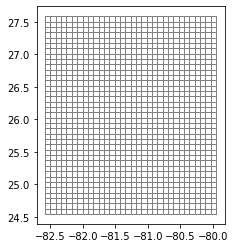

In [164]:
cell.plot(facecolor="none", edgecolor='grey')

<AxesSubplot:>

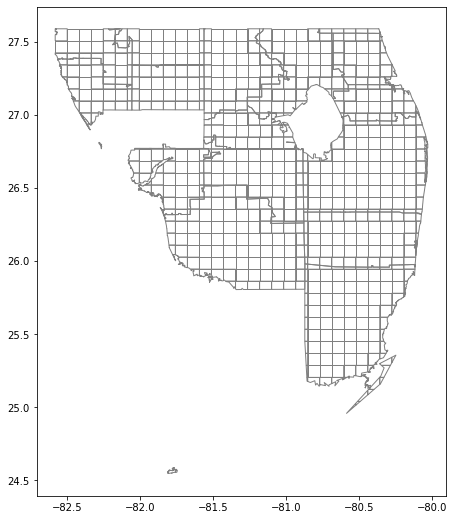

In [165]:
gpd.overlay(cell, gdf, how='intersection').plot(figsize=(16,9),facecolor="none", edgecolor='grey')

In [166]:
centroid  = cell.iloc[insect_grid.index_right.unique()].centroid
bounds =  cell.iloc[insect_grid.index_right.unique()].bounds
centroid.to_csv("centroid.csv")

PermissionError: [Errno 13] Permission denied: 'centroid.csv'

In [154]:
centroid

1094    POINT (-80.15464 26.31311)
1131    POINT (-80.07235 26.31311)
1057    POINT (-80.23693 26.31311)
1053    POINT (-80.23693 25.98393)
1090    POINT (-80.15464 25.98393)
                   ...            
1007    POINT (-80.31923 25.24329)
893     POINT (-80.56611 24.99641)
930     POINT (-80.48381 24.99641)
968     POINT (-80.40152 25.07871)
931     POINT (-80.48381 25.07871)
Length: 641, dtype: geometry